Shape: (2240, 29)

Columns:
 Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')
Data Cleaning Done!


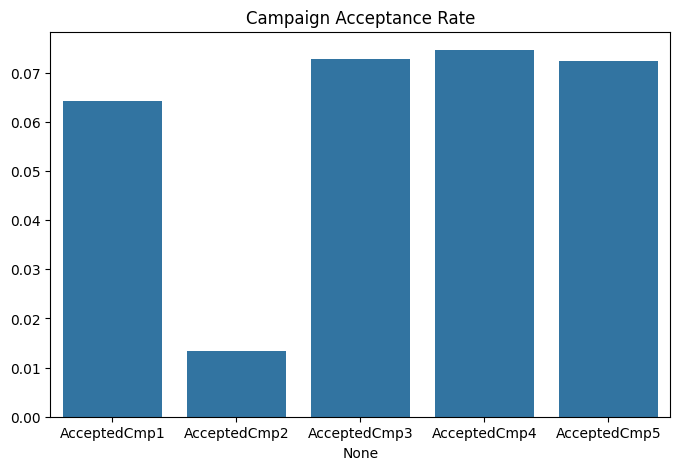

Conversion Rate: 0.14930710773357175


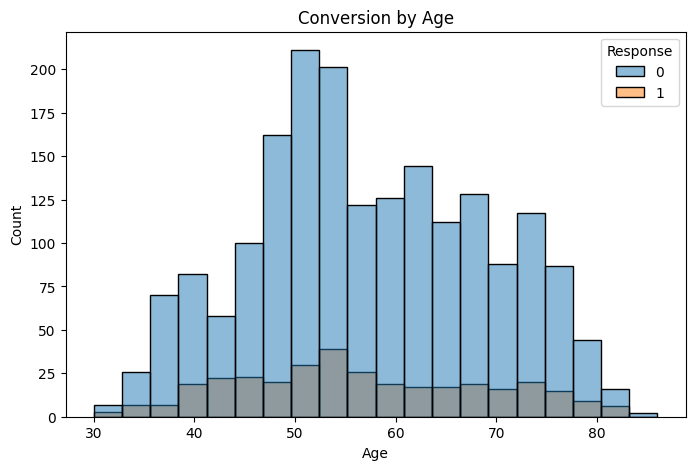

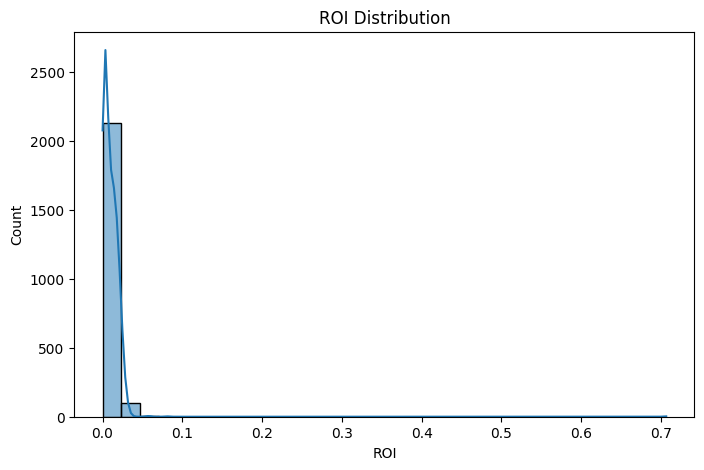

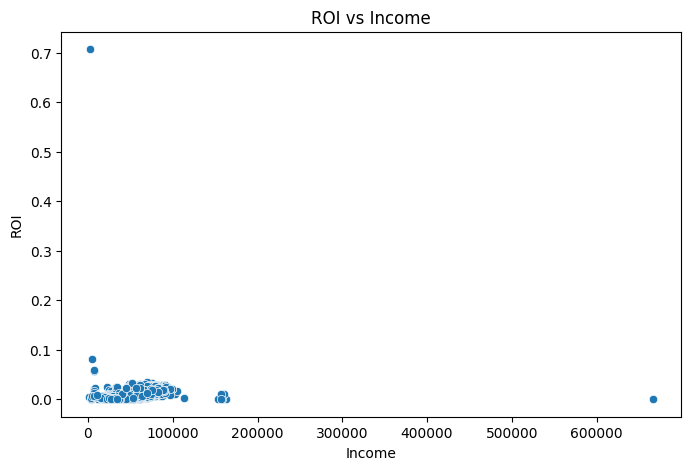

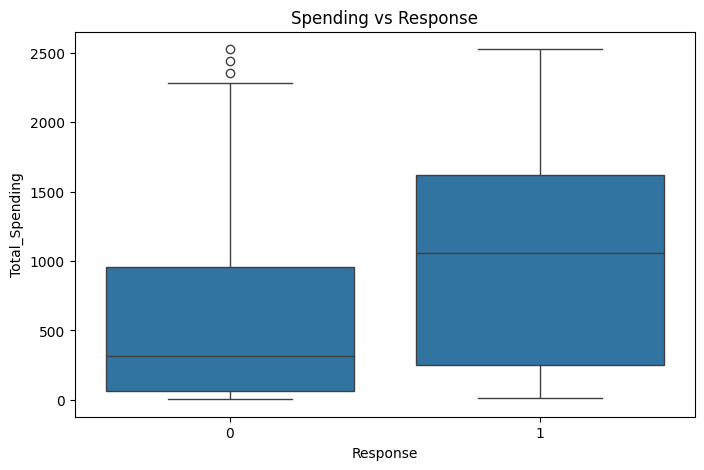

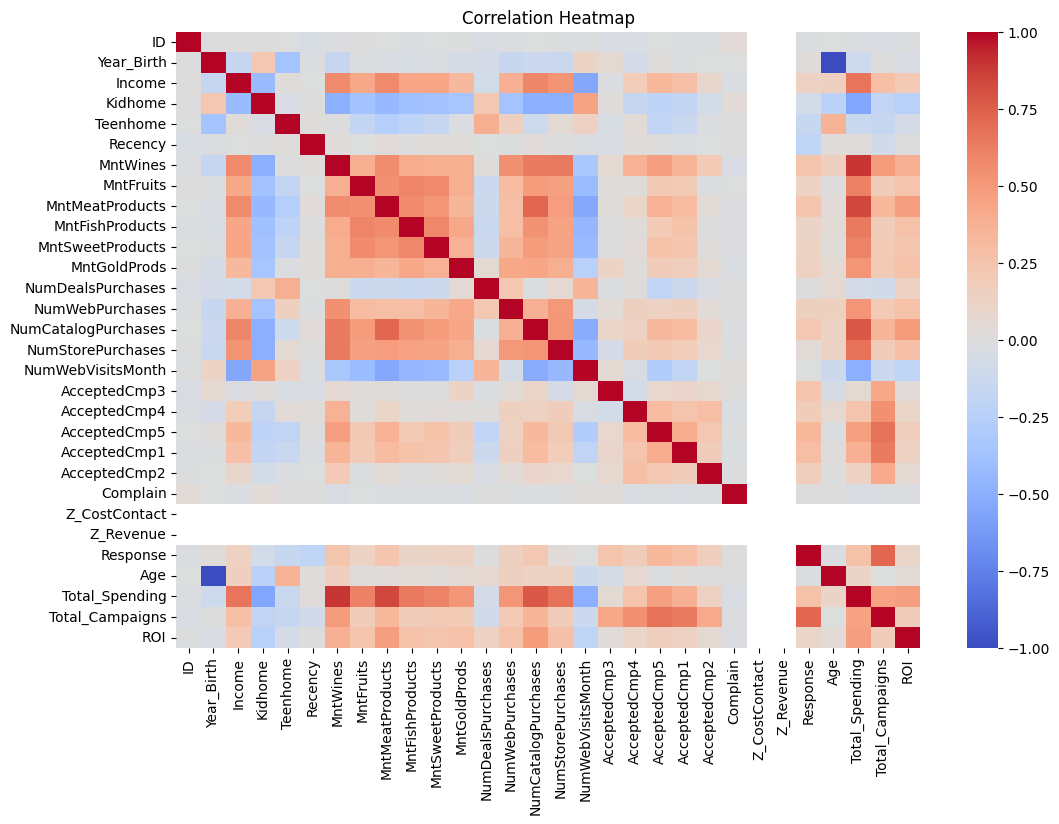

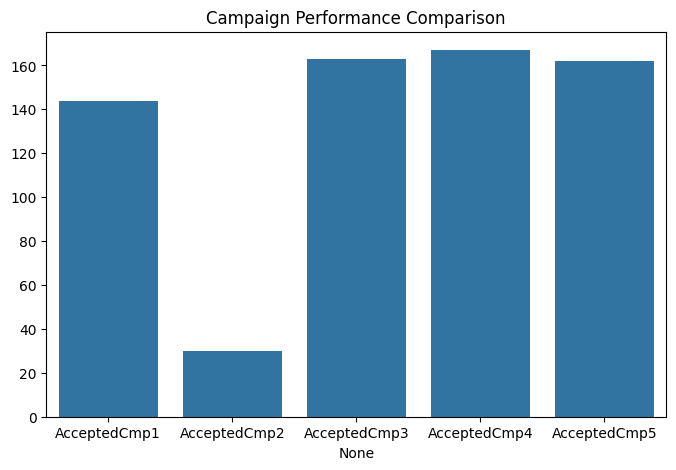

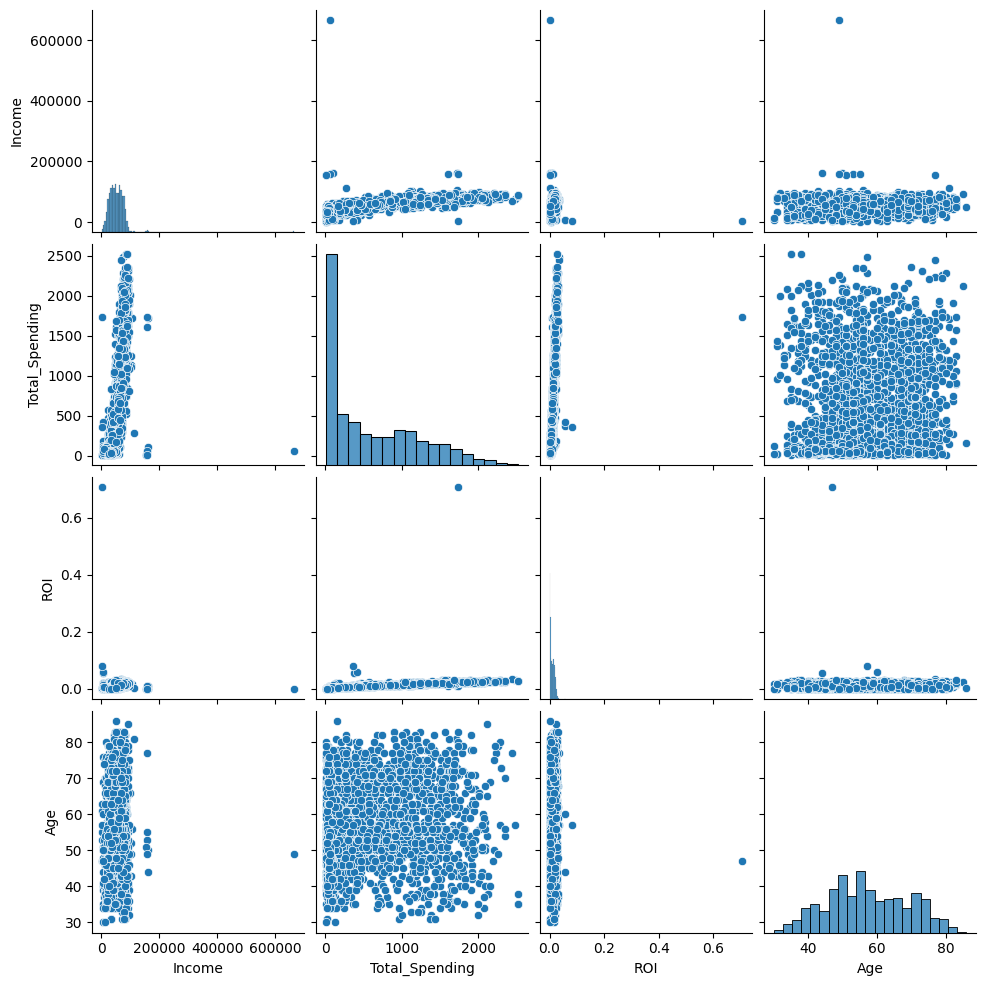

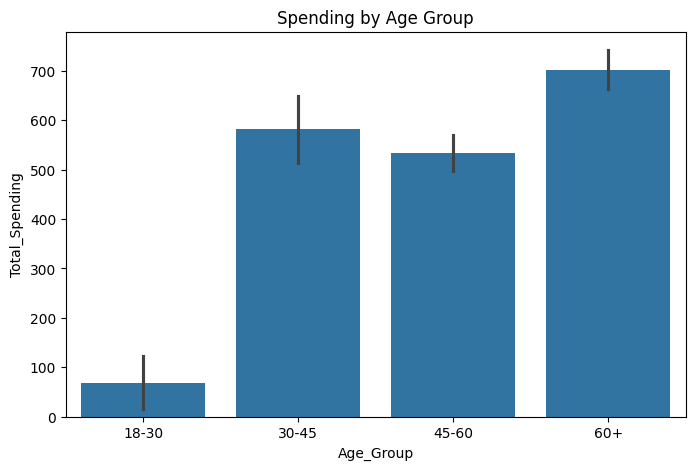

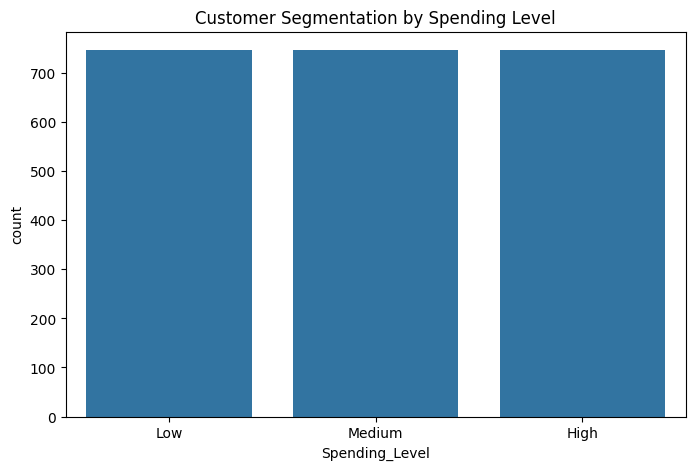

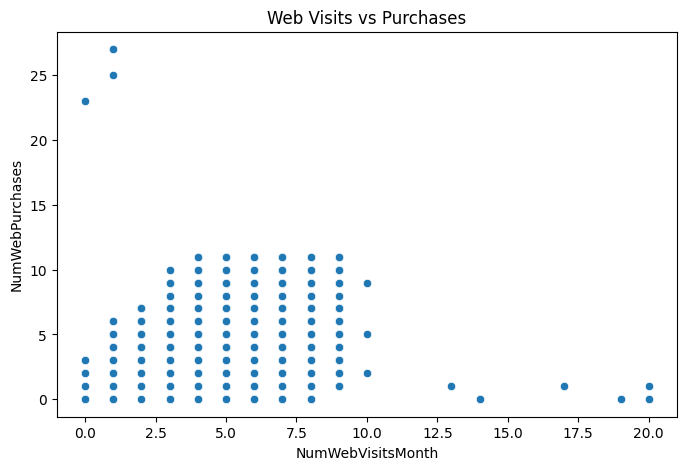

Model Accuracy: 0.8504464285714286

===== KEY INSIGHTS =====
1. Best performing campaign: AcceptedCmp4
2. Average ROI: 0.0099093462254163
3. Conversion rate: 0.14930710773357175

===== RECOMMENDATIONS =====
✔ Focus on best-performing campaigns
✔ Target high-income customers
✔ Improve low-performing campaigns
✔ Personalize marketing strategies
✔ Focus on high-spending customer segments


In [7]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

pd.set_option('display.max_columns', None)

# ==============================
# STEP 2: Load Dataset from Google Drive
# ==============================

# Replace YOUR_FILE_ID with your actual Google Drive file ID
url = "https://drive.google.com/uc?id=1P3nYfup7uzeYiK-bx9wTqkkynuz7CRjR"
df = pd.read_csv(url, sep='\t')

df.head()

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

# ==============================
# STEP 3: Data Cleaning
# ==============================
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

df['Age'] = 2026 - df['Year_Birth']
df = df[df['Age'] < 100]

print("Data Cleaning Done!")

# ==============================
# STEP 4: Feature Engineering
# ==============================
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                          'MntFishProducts','MntSweetProducts',
                          'MntGoldProds']].sum(axis=1)

df['Total_Campaigns'] = df[['AcceptedCmp1','AcceptedCmp2',
                           'AcceptedCmp3','AcceptedCmp4',
                           'AcceptedCmp5','Response']].sum(axis=1)

df['ROI'] = df['Total_Spending'] / (df['Income'] + 1)

# ==============================
# STEP 5: Campaign Analysis
# ==============================
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']

campaign_success = df[campaign_cols].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=campaign_success.index, y=campaign_success.values)
plt.title("Campaign Acceptance Rate")
plt.show()

# ==============================
# STEP 6: Conversion Analysis
# ==============================
conversion_rate = df['Response'].mean()
print("Conversion Rate:", conversion_rate)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Response', bins=20)
plt.title("Conversion by Age")
plt.show()

# ==============================
# STEP 7: ROI Analysis
# ==============================
plt.figure(figsize=(8,5))
sns.histplot(df['ROI'], bins=30, kde=True)
plt.title("ROI Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Income', y='ROI', data=df)
plt.title("ROI vs Income")
plt.show()

# ==============================
# STEP 8: Customer Behavior
# ==============================
plt.figure(figsize=(8,5))
sns.boxplot(x='Response', y='Total_Spending', data=df)
plt.title("Spending vs Response")
plt.show()

# ==============================
# STEP 9: Correlation Heatmap
# ==============================
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ==============================
# STEP 10: Campaign Comparison
# ==============================
campaign_performance = df[campaign_cols].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=campaign_performance.index, y=campaign_performance.values)
plt.title("Campaign Performance Comparison")
plt.show()

# ==============================
# STEP 11: Advanced Visualization
# ==============================
sns.pairplot(df[['Income','Total_Spending','ROI','Age']])
plt.show()

# Age Groups
df['Age_Group'] = pd.cut(df['Age'], bins=[18,30,45,60,100],
                         labels=['18-30','30-45','45-60','60+'])

plt.figure(figsize=(8,5))
sns.barplot(x='Age_Group', y='Total_Spending', data=df)
plt.title("Spending by Age Group")
plt.show()

# ==============================
# Customer Segmentation
# ==============================
df['Spending_Level'] = pd.qcut(df['Total_Spending'], q=3,
                               labels=['Low','Medium','High'])

plt.figure(figsize=(8,5))
sns.countplot(x='Spending_Level', data=df)
plt.title("Customer Segmentation by Spending Level")
plt.show()

# ==============================
# Purchase Behavior
# ==============================
plt.figure(figsize=(8,5))
sns.scatterplot(x='NumWebVisitsMonth', y='NumWebPurchases', data=df)
plt.title("Web Visits vs Purchases")
plt.show()

# ==============================
# Machine Learning Model
# ==============================
X = df[['Income','Age','Total_Spending']]
y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

# ==============================
# STEP 12: Final Insights
# ==============================
print("\n===== KEY INSIGHTS =====")

print("1. Best performing campaign:",
      campaign_performance.idxmax())

print("2. Average ROI:",
      df['ROI'].mean())

print("3. Conversion rate:",
      conversion_rate)

print("\n===== RECOMMENDATIONS =====")
print("✔ Focus on best-performing campaigns")
print("✔ Target high-income customers")
print("✔ Improve low-performing campaigns")
print("✔ Personalize marketing strategies")
print("✔ Focus on high-spending customer segments")